# Predicciones combinadas

se ponderan las predicciones en función del error, y se comparan dichas predicciones combinadas respecto a cada una 


In [25]:
import numpy as np
import pandas as pd
import itertools
import statsmodels.api as sm
import time
import json
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")

import pandas as pd
import plotly.express as px
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")


In [26]:
date_close =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
#df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close = df_data_close.rename(columns={
    "Start date": "Date",
    "value": "original"
})

df_data_close.head()


,Date,original
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


In [43]:
# longitud de la serie 
len(date_close)

575

In [27]:
# # se grafican los datos de consumo de forma semanal
fig = px.line(
    df_data_close, #dataframe
    x="Date",
    y="original",
    labels={ # etiquetas para los ejes
        "Date": "Fecha",
        "original": "Consumo"
    },
    template="plotly_white" #estilos
)

fig.update_traces(
    name="Demanda", #props de la gráfica
    line=dict(color="black"),
    showlegend=True
)

#margenes y medidas de la gráfica
fig.update_layout(
    width=1200,
    height=600,
    legend_title_text="",
    margin=dict(l=60, r=30, t=30, b=60),
    plot_bgcolor="white",
    paper_bgcolor="white"
)
# eje horizontal y malla
fig.update_xaxes(
    tickformat="%Y-%m-%d",
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1,
    automargin=True
)
# eje vertical y malla
fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1,
    automargin=True
)

fig.show()

In [28]:
# se cargan las predicciones y las medianas de los mapes correspondientes
folder_route = "../../../data/preds_energy_models/"
list_files = [
    "neuralprophet_preds.json",
    "rnn_preds.json",
    "xgboost_preds_v2.json",
    # "xgboost_preds_v2.json", -- ORIGINAL
    "SARIMA_preds.json",
]

list_preds_and_mapes = []  # se guardan los errores promedio y las predicciones
for element in list_files: # recorre los nombres
    path = os.path.join(folder_route, element) #abre el json de nombre correspondiente
    with open(path, "r") as f: # lo abre en modo lectura
        data = json.load(f) # carga la info del archivo
        
        base_name = element.replace(".json", "") # quita la extensión .json del nombre
        preds = data["predictions"], # data devuelve la info dentro de un array, por eso se toma la primera posición
        
        list_preds_and_mapes.append({
            "name": base_name, # nombre del modelo asociado
            "mape_val": float(data["mape_val"]), # registro media mape
            "mae_val":  float(data["mae_val"]), # registro mediamediana mae
            "smape_val": float(data["smape_val"]), # registro media rmse
            "rmse_val": float(data["rmse_val"]), # registro media rmse
            "forecasts": preds[0],
        })
list_preds_and_mapes[2]

{'name': 'xgboost_preds_v2',
 'mape_val': 0.027663684520542485,
 'mae_val': 35317.64760262724,
 'smape_val': 0.02752765314693563,
 'rmse_val': 47089.46813946579,
 'forecasts': [{'Date': '2024-12-02', 'pred': 1390645.25},
  {'Date': '2024-12-09', 'pred': 1373664.875},
  {'Date': '2024-12-16', 'pred': 1384503.875},
  {'Date': '2024-12-23', 'pred': 1310087.5},
  {'Date': '2024-12-30', 'pred': 1307360.0},
  {'Date': '2025-01-06', 'pred': 1269734.625},
  {'Date': '2025-01-13', 'pred': 1383025.25},
  {'Date': '2025-01-20', 'pred': 1461497.875},
  {'Date': '2025-01-27', 'pred': 1448955.625},
  {'Date': '2025-02-03', 'pred': 1392504.875},
  {'Date': '2025-02-10', 'pred': 1363926.0},
  {'Date': '2025-02-17', 'pred': 1373820.0},
  {'Date': '2025-02-24', 'pred': 1405802.375},
  {'Date': '2025-03-03', 'pred': 1338161.5},
  {'Date': '2025-03-10', 'pred': 1335074.5},
  {'Date': '2025-03-17', 'pred': 1310422.0},
  {'Date': '2025-03-24', 'pred': 1279894.25},
  {'Date': '2025-03-31', 'pred': 1260047.0}

Se valida que las longitudes de los arrays de predicciones de cada modelo tengan la misma longitud

In [29]:
for element in list_preds_and_mapes:
    print(f"modelo: {element['name']}, logitud: {len(element['forecasts'])}")

modelo: neuralprophet_preds, logitud: 58
modelo: rnn_preds, logitud: 58
modelo: xgboost_preds_v2, logitud: 58
modelo: SARIMA_preds, logitud: 58


Se formatean las predicciones 

In [30]:
rnn_preds = None
xgboost_preds = None
neuralprophet_preds = None
SARIMA_manual_preds = None

for item in list_preds_and_mapes:
    if item["name"] == "rnn_preds":
        rnn_preds = item["forecasts"]
        break

for item in list_preds_and_mapes:
    # if item["name"] == "xgboost_preds":
    if item["name"] == "xgboost_preds_v2":
        xgboost_preds = item["forecasts"]
        break

for item in list_preds_and_mapes:
    if item["name"] == "neuralprophet_preds":
        neuralprophet_preds = item["forecasts"]
        break

for item in list_preds_and_mapes:
    if item["name"] == "SARIMA_preds":
        SARIMA_preds = item["forecasts"]
        break



se crean dataframes con las preds

In [31]:
data_rnn = pd.DataFrame({
    "Date": [el["Date"] for el in rnn_preds],
    "Pred_RNN": [el["pred"] for el in rnn_preds]
})

data_SARIMA = pd.DataFrame({
    "Date": [el["Date"] for el in SARIMA_preds],
    "Pred_SARIMA": [el["pred"] for el in SARIMA_preds]
})

data_xgboost  = pd.DataFrame({
    "Date": [el["Date"] for el in xgboost_preds],
    "Pred_xgboost": [el["pred"] for el in xgboost_preds]
})

data_neuralprophet = pd.DataFrame({
    "Date": [el["Date"] for el in neuralprophet_preds],
    "Pred_neuralprophet": [el["pred"] for el in neuralprophet_preds]
})

# se toman las predicciones de SARIMA que tienen la misma fecha
data_preds = data_rnn.merge(
    data_SARIMA,
    how="inner",
    on="Date"
)

# se une el df con las preds de neural prophet
data_preds = data_preds.merge(
    data_neuralprophet,
    how="inner",
    on="Date"
).merge(
    data_xgboost,
    how="inner",
    on="Date"
).merge(
    df_data_close,
    how="inner",
    on="Date"
)
data_preds.head()


,Date,Pred_RNN,Pred_SARIMA,Pred_neuralprophet,Pred_xgboost,original
0,2024-12-02,1379474.625,1.468724e+06,1430897.875,1390645.250,1.419463e+06
1,2024-12-09,1374548.875,1.453211e+06,1421079.375,1373664.875,1.442723e+06
2,2024-12-16,1375478.375,1.427748e+06,1397550.625,1384503.875,1.422410e+06
3,2024-12-23,1375993.125,1.321395e+06,1393556.000,1310087.500,1.333686e+06
4,2024-12-30,1322380.250,1.259956e+06,1371780.625,1307360.000,1.150707e+06


In [32]:
split = df_data_close.iloc[-len(data_preds)]["Date"]
split

'2024-12-02'

se crea predicción combinada en función de los inversos de los mapes

In [33]:
# diccionario que guarda los mapes de cada modelo
mapes_list = {
    element["name"]: element["mape_val"] for element in list_preds_and_mapes
}
mapes_list

{'neuralprophet_preds': 0.032719377994307415,
 'rnn_preds': 0.029926634861861,
 'xgboost_preds_v2': 0.027663684520542485,
 'SARIMA_preds': 0.04066826242899603}

In [34]:
# pesos inversamente proporcionales al MAPE
inv_mapes_list = {k: 1/v for k, v in mapes_list.items()}

# suma de los inversos
sum_inv_mapes = sum(inv_mapes_list.values())

# normalización correcta
weights_list = {k: v / sum_inv_mapes for k, v in inv_mapes_list.items()}

sum(weights_list.values())  # debe dar 1

1.0000000000000002

In [46]:
# se guardan los pesos obtenidos
weights_list
with open("../../../data/best_train_models/ensemble_weights_frozen.json", "w") as f:
    json.dump(weights_list, f, indent=4)

In [47]:
# predicción combinada

data_preds["pred_emsemble"] = (weights_list["rnn_preds"] * data_preds["Pred_RNN"] +
    weights_list["SARIMA_preds"] * data_preds["Pred_SARIMA"] +
    weights_list["neuralprophet_preds"] * data_preds["Pred_neuralprophet"] +
    #weights_list["xgboost_preds"] * data_preds["Pred_xgboost"])
    weights_list["xgboost_preds_v2"] * data_preds["Pred_xgboost"])

data_preds.head()

,Date,Pred_RNN,Pred_SARIMA,Pred_neuralprophet,Pred_xgboost,original,pred_ensemble,pred_emsemble
0,2024-12-02,1379474.625,1.468724e+06,1430897.875,1390645.250,1.419463e+06,1.412911e+06,1.412911e+06
1,2024-12-09,1374548.875,1.453211e+06,1421079.375,1373664.875,1.442723e+06,1.401205e+06,1.401205e+06
2,2024-12-16,1375478.375,1.427748e+06,1397550.625,1384503.875,1.422410e+06,1.393809e+06,1.393809e+06
3,2024-12-23,1375993.125,1.321395e+06,1393556.000,1310087.500,1.333686e+06,1.350430e+06,1.350430e+06
4,2024-12-30,1322380.250,1.259956e+06,1371780.625,1307360.000,1.150707e+06,1.317825e+06,1.317825e+06


In [36]:
data_preds.columns

Index(['Date', 'Pred_RNN', 'Pred_SARIMA', 'Pred_neuralprophet', 'Pred_xgboost',
       'original', 'pred_emsemble'],
      dtype='object')

In [37]:
# comparación metricas preds ensemble
# métricas de error

y_true = data_preds["original"].values
y_pred_ensemble = data_preds["pred_emsemble"].values
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred_ensemble)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_ensemble))
mape = mean_absolute_percentage_error(y_true, y_pred_ensemble)
smape = smape_fn(y_true, y_pred_ensemble)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")

MAE: 33784.400140810154
RMSE: 45880.66117606484
MAPE: 2.6482%
sMAPE: 2.6313%


In [38]:
orden_series = [
    "Train",
    "Test",
    "Pred. RNN",
    "Pred. SARIMA",
    "Pred. NeuralProphet",
    "Pred. XGBoost",
    "Pred. Ensemble"
]

In [39]:
# Limpiar nombres de columnas
data_preds.columns = (
    data_preds.columns
    .astype(str)
    .str.strip()        # quita espacios
    .str.strip('"')     # quita comillas dobles
    .str.strip("'")     # quita comillas simples, si existieran
)

# corregir definitivamente el nombre del ensamble
data_preds = data_preds.rename(
    columns={"pred_emsemble": "pred_ensemble"}
)

# comprobación
print(data_preds.columns.tolist())
print("¿Existe pred_ensemble?:", "pred_ensemble" in data_preds.columns)

['Date', 'Pred_RNN', 'Pred_SARIMA', 'Pred_neuralprophet', 'Pred_xgboost', 'original', 'pred_ensemble']
¿Existe pred_ensemble?: True


In [40]:
# %% [markdown]
# ### Gráfica de predicciones individuales y predicción combinada

# %%
import pandas as pd
import plotly.graph_objects as go

# ============================================================
# 1. Preparación de datos
# ============================================================

# asegurar formato datetime
df_data_close["Date"] = pd.to_datetime(df_data_close["Date"])
data_preds["Date"] = pd.to_datetime(data_preds["Date"])

# ordenar cronológicamente
df_data_close = (
    df_data_close
    .sort_values("Date")
    .reset_index(drop=True)
)

data_preds = (
    data_preds
    .sort_values("Date")
    .reset_index(drop=True)
)

# validar que existan las columnas necesarias
columnas_requeridas = [
    "Date",
    "original",
    "Pred_RNN",
    "Pred_SARIMA",
    "Pred_neuralprophet",
    "Pred_xgboost",
    "pred_ensemble"
]

columnas_faltantes = [
    col for col in columnas_requeridas
    if col not in data_preds.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan las siguientes columnas en data_preds: "
        f"{columnas_faltantes}"
    )

# primera fecha del conjunto de prueba
split = data_preds["Date"].min()

# cantidad de observaciones anteriores al test
# que se desean mostrar en la gráfica
n_train_plot = 20

# últimas observaciones del entrenamiento
train_plot = (
    df_data_close[
        df_data_close["Date"] < split
    ]
    .sort_values("Date")
    .tail(n_train_plot)
    .copy()
)

# ============================================================
# 2. Creación de la figura
# ============================================================

fig = go.Figure()

# ----------------------------
# Entrenamiento
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=train_plot["Date"],
        y=train_plot["original"],
        mode="lines",
        name="Entrenamiento",
        line=dict(
            color="#8A8A8A",
            width=2
        ),
        opacity=0.9
    )
)

# ----------------------------
# Valores reales - Test
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=data_preds["Date"],
        y=data_preds["original"],
        mode="lines",
        name="Prueba",
        line=dict(
            color="#202020",
            width=2.5
        ),
        opacity=1
    )
)

# ----------------------------
# Predicción RNN
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=data_preds["Date"],
        y=data_preds["Pred_RNN"],
        mode="lines",
        name="RNN",
        line=dict(
            color="#8064A2",
            width=1.5
        ),
        opacity=0.7
    )
)

# ----------------------------
# Predicción SARIMA
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=data_preds["Date"],
        y=data_preds["Pred_SARIMA"],
        mode="lines",
        name="SARIMA",
        line=dict(
            color="#C77C32",
            width=1.5
        ),
        opacity=0.7
    )
)

# ----------------------------
# Predicción NeuralProphet
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=data_preds["Date"],
        y=data_preds["Pred_neuralprophet"],
        mode="lines",
        name="NeuralProphet",
        line=dict(
            color="#3297A8",
            width=1.5
        ),
        opacity=0.7
    )
)

# ----------------------------
# Predicción XGBoost
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=data_preds["Date"],
        y=data_preds["Pred_xgboost"],
        mode="lines",
        name="XGBoost",
        line=dict(
            color="#C75C7A",
            width=1.5
        ),
        opacity=0.7
    )
)

# ----------------------------
# Predicción combinada
# ----------------------------
fig.add_trace(
    go.Scatter(
        x=data_preds["Date"],
        y=data_preds["pred_ensemble"],
        mode="lines",
        name="Ensamble",
        line=dict(
            color="#C00000",
            width=3
        ),
        opacity=1
    )
)

# ============================================================
# 3. Separación Train / Test
# ============================================================

fig.add_vline(
    x=split,
    line_color="#555555",
    line_width=1.2,
    line_dash="dash"
)

fig.add_annotation(
    x=split,
    y=0.98,
    yref="paper",
    text="Inicio del conjunto de prueba",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    xshift=6,
    font=dict(
        size=12,
        color="#444444"
    ),
    bgcolor="rgba(255,255,255,0.8)"
)

# ============================================================
# 4. Formato general
# ============================================================

fig.update_layout(
    width=1100,
    height=620,

    title=None,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#222222"
    ),

    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.18,
        xanchor="center",
        x=0.5,
        font=dict(size=12),
        title_text="",
        itemsizing="constant"
    ),

    margin=dict(
        l=90,
        r=30,
        t=30,
        b=120
    ),

    hovermode="x unified"
)

# ============================================================
# 5. Eje X
# ============================================================

fig.update_xaxes(
    title=dict(
        text="Fecha",
        font=dict(size=17)
    ),
    tickfont=dict(size=12),
    tickformat="%Y-%m",
    dtick="M2",
    showgrid=True,
    gridcolor="#E5E5E5",
    gridwidth=0.8,
    showline=True,
    linecolor="#777777",
    linewidth=1,
    automargin=True
)

# ============================================================
# 6. Eje Y
# ============================================================

fig.update_yaxes(
    title=dict(
        text="Consumo energético (MWh)",
        font=dict(size=17)
    ),
    tickfont=dict(size=12),
    tickformat=".3s",
    showgrid=True,
    gridcolor="#D9D9D9",
    gridwidth=0.8,
    showline=True,
    linecolor="#777777",
    linewidth=1,
    automargin=True
)

# ============================================================
# 7. Mostrar y exportar
# ============================================================

fig.show()

fig.write_image(
    "../../../data/preds_energy_models/images/predicciones_ensemble.png",
    width=1100,
    height=620,
    scale=3
)

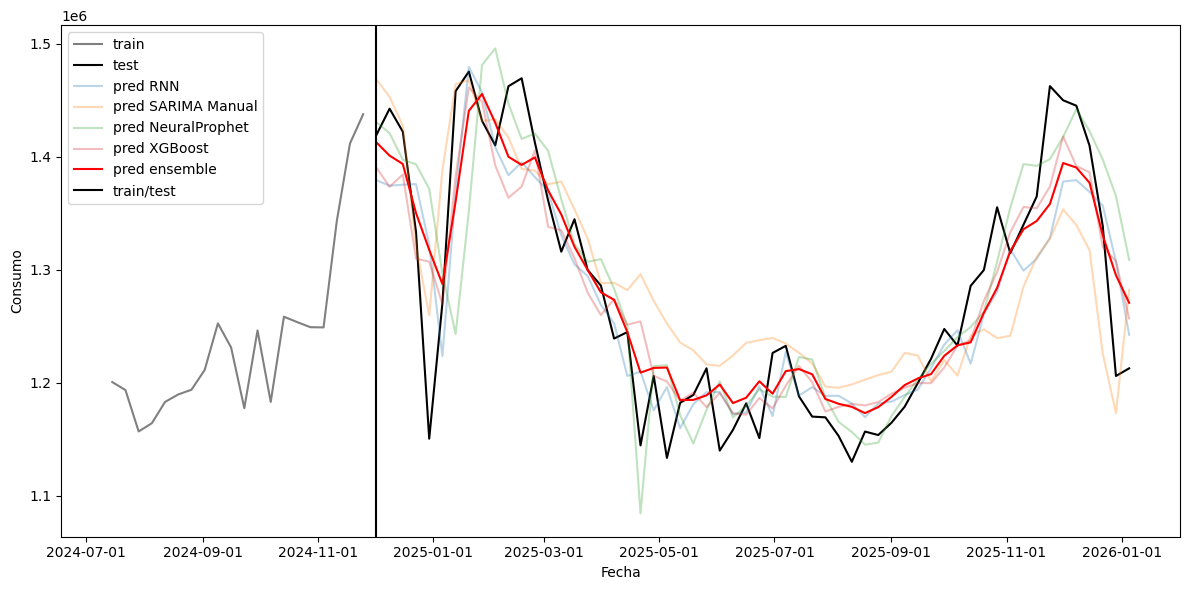

In [41]:
# grpafica con ensemble 
# se grafican los datos 
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(data_preds)], df_data_close["original"][:-len(data_preds)], label="train", color="gray")
plt.plot(df_data_close["Date"][-len(data_preds) - 20:-len(data_preds)], df_data_close["original"][-len(data_preds) - 20:-len(data_preds)], label="train", color="gray")
plt.plot(df_data_close["Date"][-len(data_preds):], df_data_close["original"][-len(data_preds):], label="test", color="black")
plt.plot(data_preds["Date"], data_preds["Pred_RNN"], label="pred RNN", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["Pred_SARIMA"], label="pred SARIMA Manual", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["Pred_neuralprophet"], label="pred NeuralProphet", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["Pred_xgboost"], label="pred XGBoost", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["pred_ensemble"], label="pred ensemble", alpha=1, color='red')
plt.axvline(split, color="black", label="train/test")
#plt.plot(df_data_close["Date"], df_data_close["original"], label="demanda")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [42]:
# se crea lista de mapes y demas errores para alfinal unir en una sola tabla
mapes_list["ensemble"] = mape

maes_list = {
    element["name"]: element["mae_val"] for element in list_preds_and_mapes
}
maes_list["ensemble"] = mae

rmse_list = {
    element["name"]: element["rmse_val"] for element in list_preds_and_mapes
}
rmse_list["ensemble"] = rmse

smapes_list = {
    element["name"]: element["smape_val"] for element in list_preds_and_mapes
}
smapes_list["ensemble"] = smape

# se construyen los datasets

errors_df = pd.DataFrame({
    "modelo": [el.replace("_preds", "") for el in mapes_list.keys()],
    "mape": [f"{el * 100:.4f}%" for el in mapes_list.values()],
    "smape": [f"{el * 100:.4f}%" for el in smapes_list.values()],
    "mae": maes_list.values(),
    "rmse": rmse_list.values(),
})

errors_df.sort_values(by="mape")


,modelo,mape,smape,mae,rmse
4,ensemble,2.6482%,2.6313%,33784.400141,45880.661176
2,xgboost_v2,2.7664%,2.7528%,35317.647603,47089.468139
1,rnn,2.9927%,2.9934%,38567.141297,50811.059375
0,neuralprophet,3.2719%,3.2386%,41914.778994,61364.957839
3,SARIMA,4.0668%,4.0362%,51313.516011,63161.652014
